# Targeted finetune learning-curve analysis

This notebook analyzes the focused threshold-1 sweep in `lib1_enhancer_targeted_apr2026`.

Run command:
```bash
python boda2_EU/src/finetune/finetune_sweep_scripts/lib1_enhancer_learning_curve_finetune_updated.py --outdir /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_targeted_apr2026 --include_b1 --include_b2 --include_b3 --b3_bcaps 10 --train_thresholds 1 --unfreeze_scopes branched_only conv3_plus full --head_lrs 2e-4 5e-4 --backbone_lrs 1e-5 1e-4 --train_size_fracs 0.05 0.1 0.2 0.35 0.5 0.75 1.0 --train_sampling_mode hq_first --val_frac_within_hq 0.25 --test_frac_within_hq 0.25 --test_min_barcodes 4 --seeds 17 23 19 31
```

What this notebook covers:
- provenance and run coverage for the targeted April 2026 follow-up,
- best-HPO selection within the narrowed grid for each `setting x unfreeze_scope`,
- train-size learning curves with `train`, `validation`, and `test` final metrics on the same axes,
- epoch dynamics from `learning_curve_histories.csv` for the metrics that were logged each epoch.

Important note:
- `learning_curve_histories.csv` contains `train_loss_standardized` plus validation metrics per epoch,
- final `train` and `test` metrics live in `learning_curve_runs.csv` / `learning_curve_summary_mean_std.csv`, not in the per-epoch history file.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RUN_DIR = Path("/home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_targeted_apr2026")

zero_shot = pd.read_csv(RUN_DIR / "zero_shot_fixed_test.csv")
runs = pd.read_csv(RUN_DIR / "learning_curve_runs.csv")
histories = pd.read_csv(RUN_DIR / "learning_curve_histories.csv")
summary = pd.read_csv(RUN_DIR / "learning_curve_summary_mean_std.csv")
scope_summary = pd.read_csv(RUN_DIR / "unfreeze_scope_summary_mean_std.csv")

with open(RUN_DIR / "run_manifest.json", "r") as f:
    manifest = json.load(f)

print("RUN_DIR:", RUN_DIR)
print("zero_shot:", zero_shot.shape)
print("runs:", runs.shape)
print("histories:", histories.shape)
print("summary:", summary.shape)
print("scope_summary:", scope_summary.shape)

RUN_DIR: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_targeted_apr2026
zero_shot: (3, 8)
runs: (3024, 71)
histories: (71222, 28)
summary: (756, 84)
scope_summary: (36, 33)


In [2]:
manifest_keys = [
    "run_id",
    "run_started_at",
    "device_resolved",
    "train_thresholds",
    "train_size_fracs",
    "train_sampling_mode",
    "unfreeze_scopes",
    "head_lrs",
    "backbone_lrs",
    "seeds",
]

manifest_view = pd.DataFrame(
    {
        "manifest_key": manifest_keys,
        "value": [manifest.get(k) for k in manifest_keys],
    }
)

SETTING_LABEL_MAP = {
    "B1_no_RC": "B1_no_RC",
    "B2_with_RC": "B2_with_RC",
    "B3_with_RC_weighted_bcap_10": "B3_RC_bcap_10",
}

train_size_order = sorted(summary["train_size"].unique().tolist())
hq_only_limit = int(runs.loc[runs["train_threshold"] == 1, "train_pool_leftover_hq_size"].mode().iloc[0])
first_mixed_train_size = min(x for x in train_size_order if x > hq_only_limit)

display(manifest_view)
print("\nSettings:", sorted(summary["setting"].unique().tolist()))
print("Init heads:", sorted(summary["init_head"].unique().tolist()))
print("Unfreeze scopes:", sorted(summary["unfreeze_scope"].unique().tolist()))
print("Train sizes:", train_size_order)
print("Train thresholds:", sorted(summary["train_threshold"].unique().tolist()))
print(
    f"HQ-only pool size before lower-quality examples enter: {hq_only_limit}; "
    f"first mixed-quality train_size in this sweep: {first_mixed_train_size}"
)

print("\nZero-shot fixed-test baseline:")
display(zero_shot.sort_values("r2", ascending=False))

,manifest_key,value
0,run_id,20260403T034826Z_7199da18
1,run_started_at,2026-04-03T03:48:26.406507+00:00
2,device_resolved,cuda
3,train_thresholds,[1]
4,train_size_fracs,"[0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]"
5,train_sampling_mode,hq_first
6,unfreeze_scopes,"[branched_only, conv3_plus, full]"
7,head_lrs,"[0.0002, 0.0005]"
8,backbone_lrs,"[1e-05, 0.0001]"
9,seeds,"[17, 23, 19, 31]"



Settings: ['B1_no_RC', 'B2_with_RC', 'B3_with_RC_weighted_bcap_10']
Init heads: ['HepG2', 'K562', 'SKNSH']
Unfreeze scopes: ['branched_only', 'conv3_plus', 'full']
Train sizes: [161, 322, 643, 1125, 1608, 2411, 3215]
Train thresholds: [1]
HQ-only pool size before lower-quality examples enter: 614; first mixed-quality train_size in this sweep: 643

Zero-shot fixed-test baseline:


,n,mae,rmse,r2,pearson,spearman,pearson_sq,init_head
0,307,1.016297,1.143187,-13.657249,0.334800,0.278844,0.112091,K562
1,307,1.023060,1.153697,-13.927995,0.303781,0.268727,0.092283,HepG2
2,307,1.086014,1.211886,-15.471817,0.324549,0.270665,0.105332,SKNSH


In [3]:
thr1_summary = summary.query("train_threshold == 1").copy()
full_train_size = int(thr1_summary["train_size"].max())
selection_keys = ["setting", "unfreeze_scope", "head_lr", "backbone_lr"]

full_train_grid = (
    thr1_summary[thr1_summary["train_size"] == full_train_size]
    .groupby(selection_keys, dropna=False)
    .agg(
        mean_val_r2=("val_r2_mean", "mean"),
        mean_test_r2=("test_r2_mean", "mean"),
        mean_val_loss=("val_loss_standardized_mean", "mean"),
        mean_test_loss=("test_loss_standardized_mean", "mean"),
        mean_best_epoch=("best_epoch_mean", "mean"),
        n_rows=("val_r2_mean", "size"),
    )
    .reset_index()
)

best_hpo = (
    full_train_grid
    .sort_values(
        ["setting", "unfreeze_scope", "mean_val_r2", "mean_test_r2", "mean_val_loss"],
        ascending=[True, True, False, False, True],
    )
    .drop_duplicates(["setting", "unfreeze_scope"])
    .sort_values(["setting", "unfreeze_scope"])
    .reset_index(drop=True)
)

print(f"Selecting one HPO point per setting/scope using full-train-size val R2 at n={full_train_size}.")
display(best_hpo)

Selecting one HPO point per setting/scope using full-train-size val R2 at n=3215.


,setting,unfreeze_scope,head_lr,backbone_lr,mean_val_r2,mean_test_r2,mean_val_loss,mean_test_loss,mean_best_epoch,n_rows
0,B1_no_RC,branched_only,0.0002,0.00001,0.149953,0.187734,0.703976,0.480768,23.416667,3
1,B1_no_RC,conv3_plus,0.0005,0.00010,0.153190,0.196654,0.701295,0.475488,4.000000,3
2,B1_no_RC,full,0.0005,0.00010,0.174971,0.196399,0.683258,0.475639,3.083333,3
3,B2_with_RC,branched_only,0.0002,0.00001,0.156328,0.186421,0.698697,0.481544,7.666667,3
4,B2_with_RC,conv3_plus,0.0002,0.00010,0.168001,0.200886,0.689030,0.472983,3.250000,3
5,B2_with_RC,full,0.0002,0.00010,0.179123,0.217222,0.679819,0.463314,2.666667,3
6,B3_with_RC_weighted_bcap_10,branched_only,0.0002,0.00001,0.160812,0.193564,0.694984,0.477317,7.916667,3
7,B3_with_RC_weighted_bcap_10,conv3_plus,0.0002,0.00010,0.174926,0.208602,0.683295,0.468416,3.416667,3
8,B3_with_RC_weighted_bcap_10,full,0.0002,0.00010,0.187409,0.222143,0.672957,0.460401,2.583333,3


In [4]:
best_keys = ["setting", "unfreeze_scope", "head_lr", "backbone_lr"]

best_runs = runs.merge(best_hpo[best_keys], on=best_keys, how="inner")
best_histories = histories.merge(best_hpo[best_keys], on=best_keys, how="inner")
best_summary = summary.merge(best_hpo[best_keys], on=best_keys, how="inner")

print("best_runs:", best_runs.shape)
print("best_histories:", best_histories.shape)
print("best_summary:", best_summary.shape)

coverage = (
    best_runs.groupby(["setting", "unfreeze_scope"], dropna=False)
    .agg(
        n_runs=("run_id", "nunique"),
        n_heads=("init_head", "nunique"),
        n_seeds=("seed", "nunique"),
        n_train_sizes=("train_size", "nunique"),
    )
    .reset_index()
    .sort_values(["setting", "unfreeze_scope"])
)

display(coverage)

best_runs: (756, 71)
best_histories: (17711, 28)
best_summary: (189, 84)


,setting,unfreeze_scope,n_runs,n_heads,n_seeds,n_train_sizes
0,B1_no_RC,branched_only,1,3,4,7
1,B1_no_RC,conv3_plus,1,3,4,7
2,B1_no_RC,full,1,3,4,7
3,B2_with_RC,branched_only,1,3,4,7
4,B2_with_RC,conv3_plus,1,3,4,7
5,B2_with_RC,full,1,3,4,7
6,B3_with_RC_weighted_bcap_10,branched_only,1,3,4,7
7,B3_with_RC_weighted_bcap_10,conv3_plus,1,3,4,7
8,B3_with_RC_weighted_bcap_10,full,1,3,4,7


In [5]:
train_size_order = sorted(best_runs["train_size"].unique().tolist())


def add_quality_transition_marker(grid):
    from matplotlib.lines import Line2D

    dash_label = f"dashed line: lower-quality samples start at train_size={first_mixed_train_size}"
    for ax in grid.axes.flat:
        if ax is not None:
            ax.axvline(first_mixed_train_size, color="black", linestyle="--", linewidth=1.0, alpha=0.6)

    vline_handle = Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.6,
        label=dash_label,
    )
    grid.fig.legend(
        handles=[vline_handle],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.01),
        frameon=False,
    )
    grid.fig.subplots_adjust(bottom=0.18)
    return grid


def plot_final_metric_vs_train_size(frame, metric_root, y_label):
    split_map = {
        f"train_{metric_root}": "train",
        f"val_{metric_root}": "validation",
        f"test_{metric_root}": "test",
    }
    plot_df = frame.melt(
        id_vars=["setting", "unfreeze_scope", "train_size", "init_head", "seed"],
        value_vars=list(split_map.keys()),
        var_name="split_metric",
        value_name="value",
    ).copy()
    plot_df["split"] = plot_df["split_metric"].map(split_map)
    plot_df["setting_label"] = plot_df["setting"].map(SETTING_LABEL_MAP).fillna(plot_df["setting"])

    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue="split",
        row="setting_label",
        col="unfreeze_scope",
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="sd",
        height=4,
        aspect=1.15,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set(xscale="log")
    g.set_axis_labels("train_size", y_label)
    g.set_titles("{row_name} | {col_name}")
    g.fig.subplots_adjust(top=0.92)
    g.fig.suptitle(f"{y_label} vs train size for selected HPO")
    add_quality_transition_marker(g)
    return g


def plot_epoch_metric(frame, metric_col, y_label):
    plot_df = frame.copy()
    plot_df["train_size_label"] = pd.Categorical(
        plot_df["train_size"].astype(str),
        categories=[str(x) for x in train_size_order],
        ordered=True,
    )
    plot_df["setting_label"] = plot_df["setting"].map(SETTING_LABEL_MAP).fillna(plot_df["setting"])

    g = sns.relplot(
        data=plot_df,
        x="epoch",
        y=metric_col,
        hue="train_size_label",
        row="setting_label",
        col="unfreeze_scope",
        kind="line",
        estimator="mean",
        errorbar="sd",
        height=4,
        aspect=1.15,
        facet_kws={"sharex": True, "sharey": False},
        palette="viridis",
    )
    g.set_axis_labels("epoch", y_label)
    g.set_titles("{row_name} | {col_name}")
    g._legend.set_title("train_size")
    g.fig.subplots_adjust(top=0.92)
    g.fig.suptitle(f"{y_label} across epochs for selected HPO")
    return g

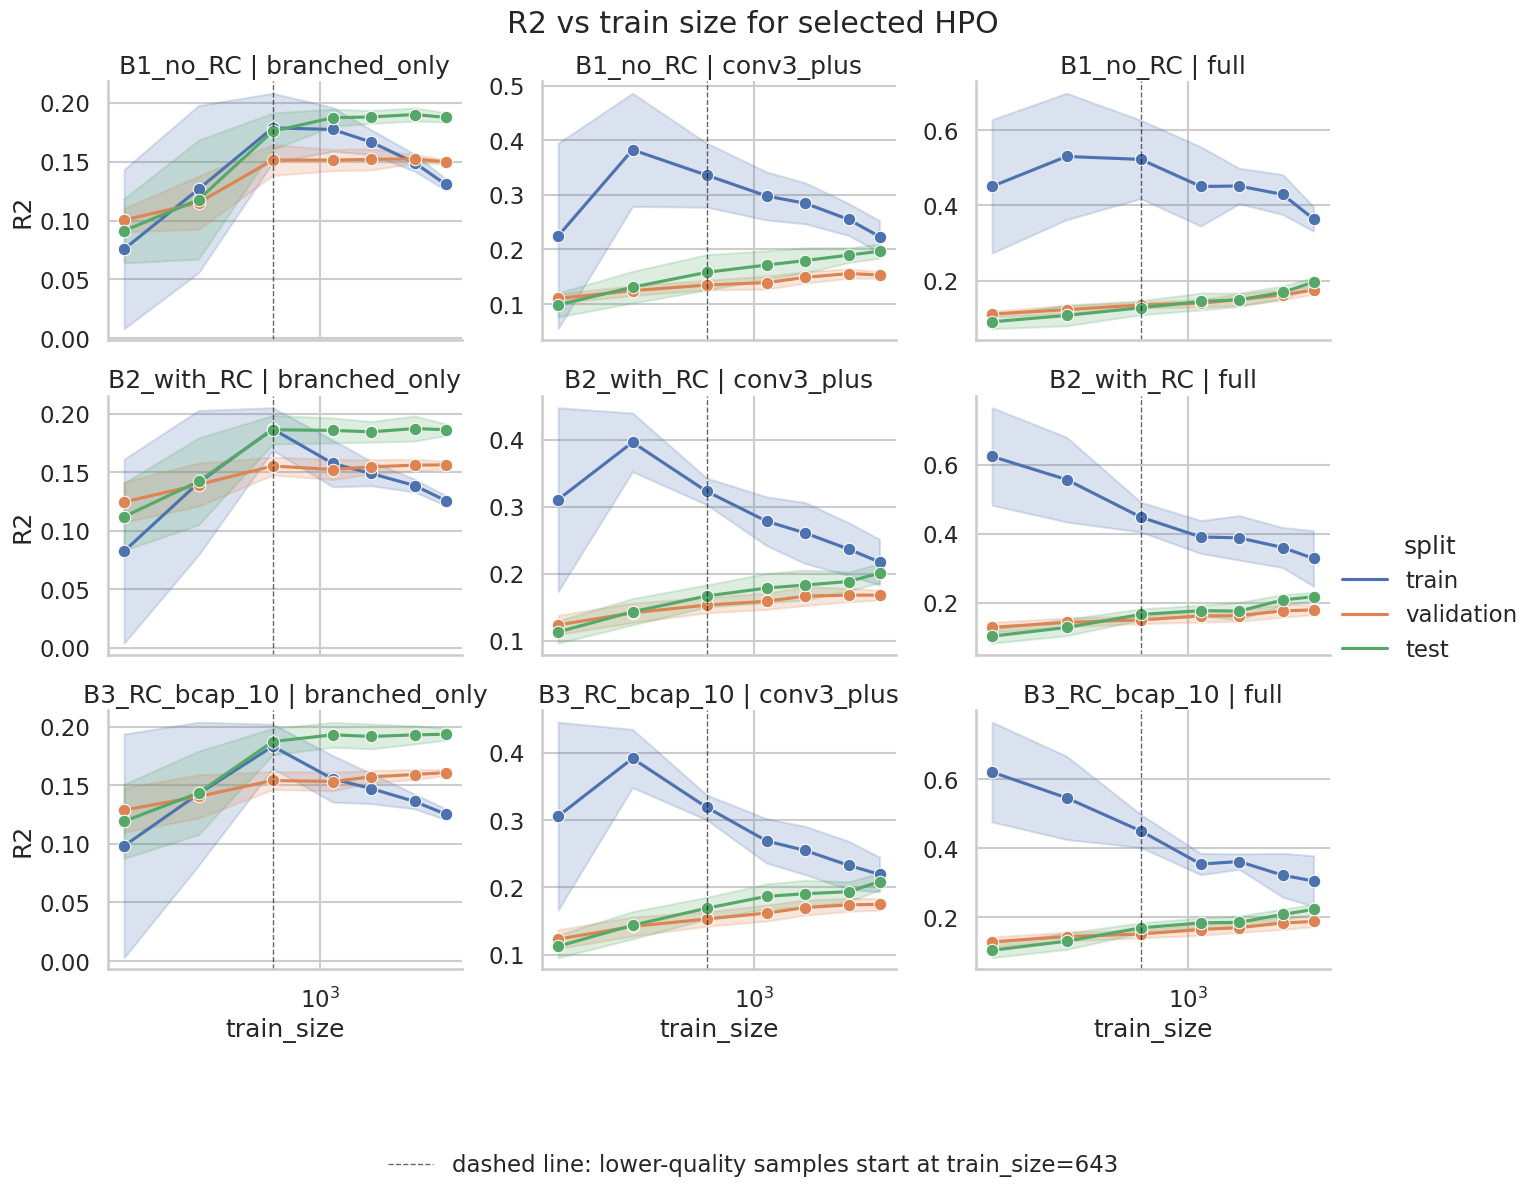

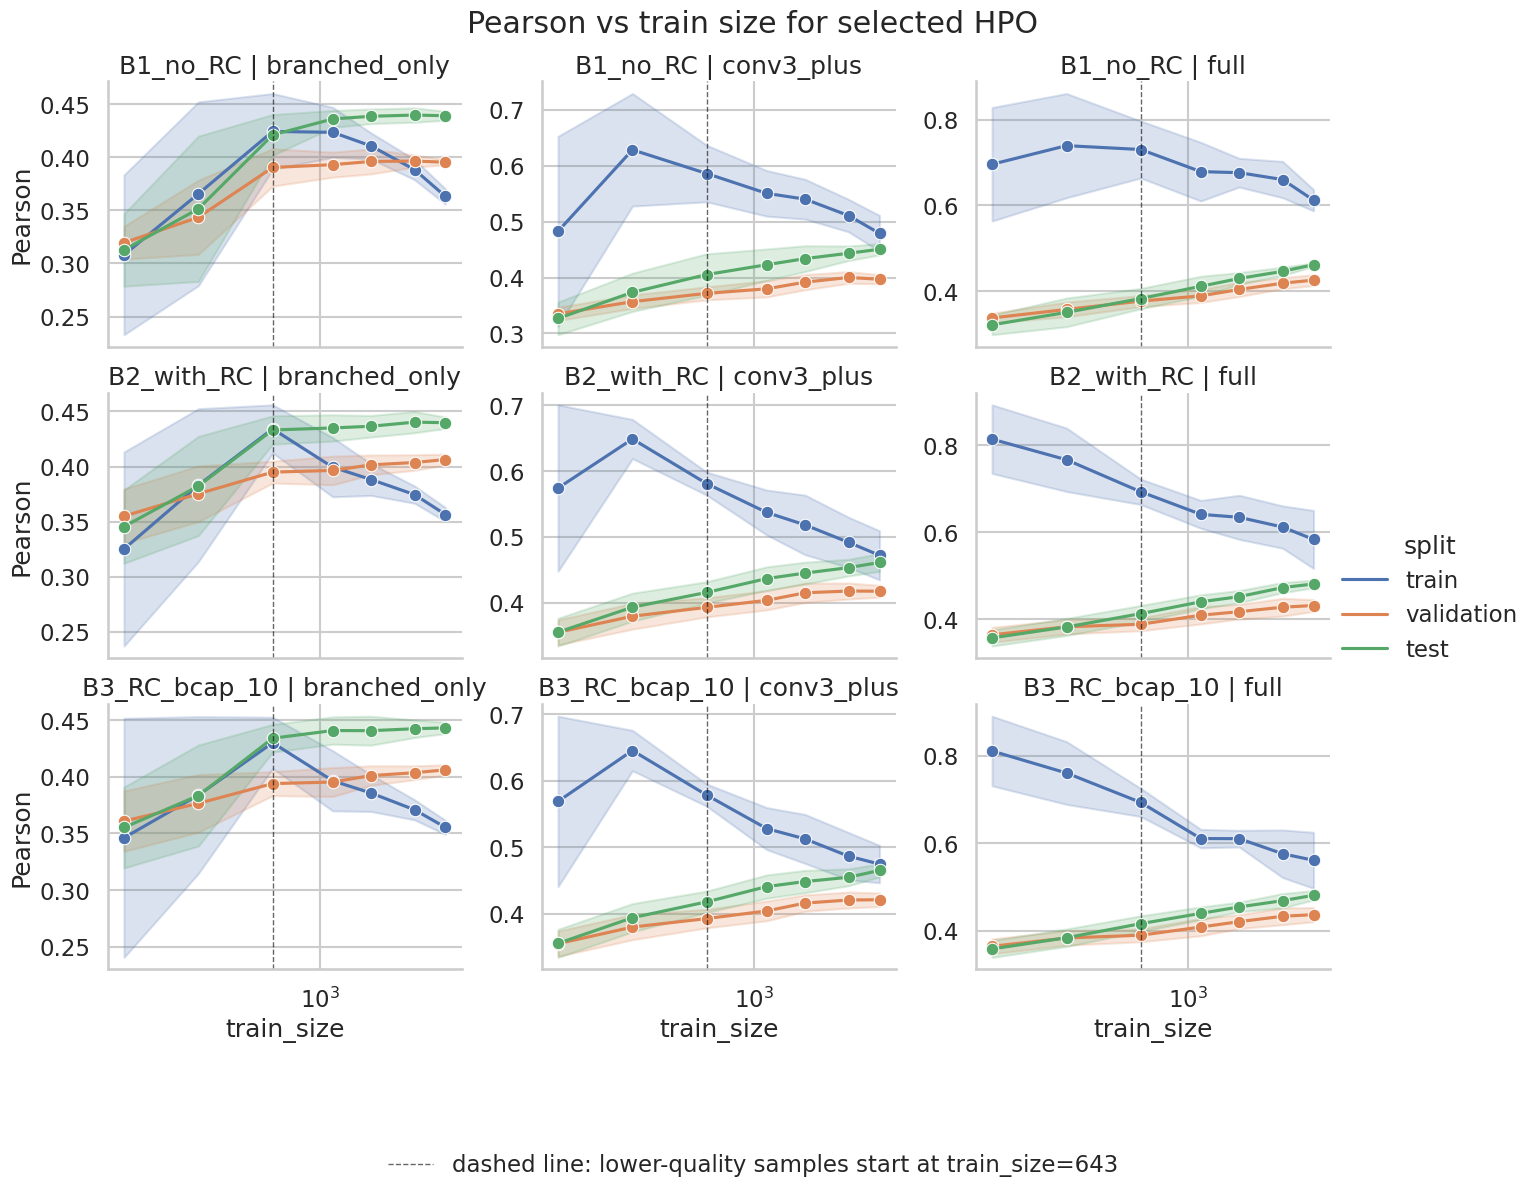

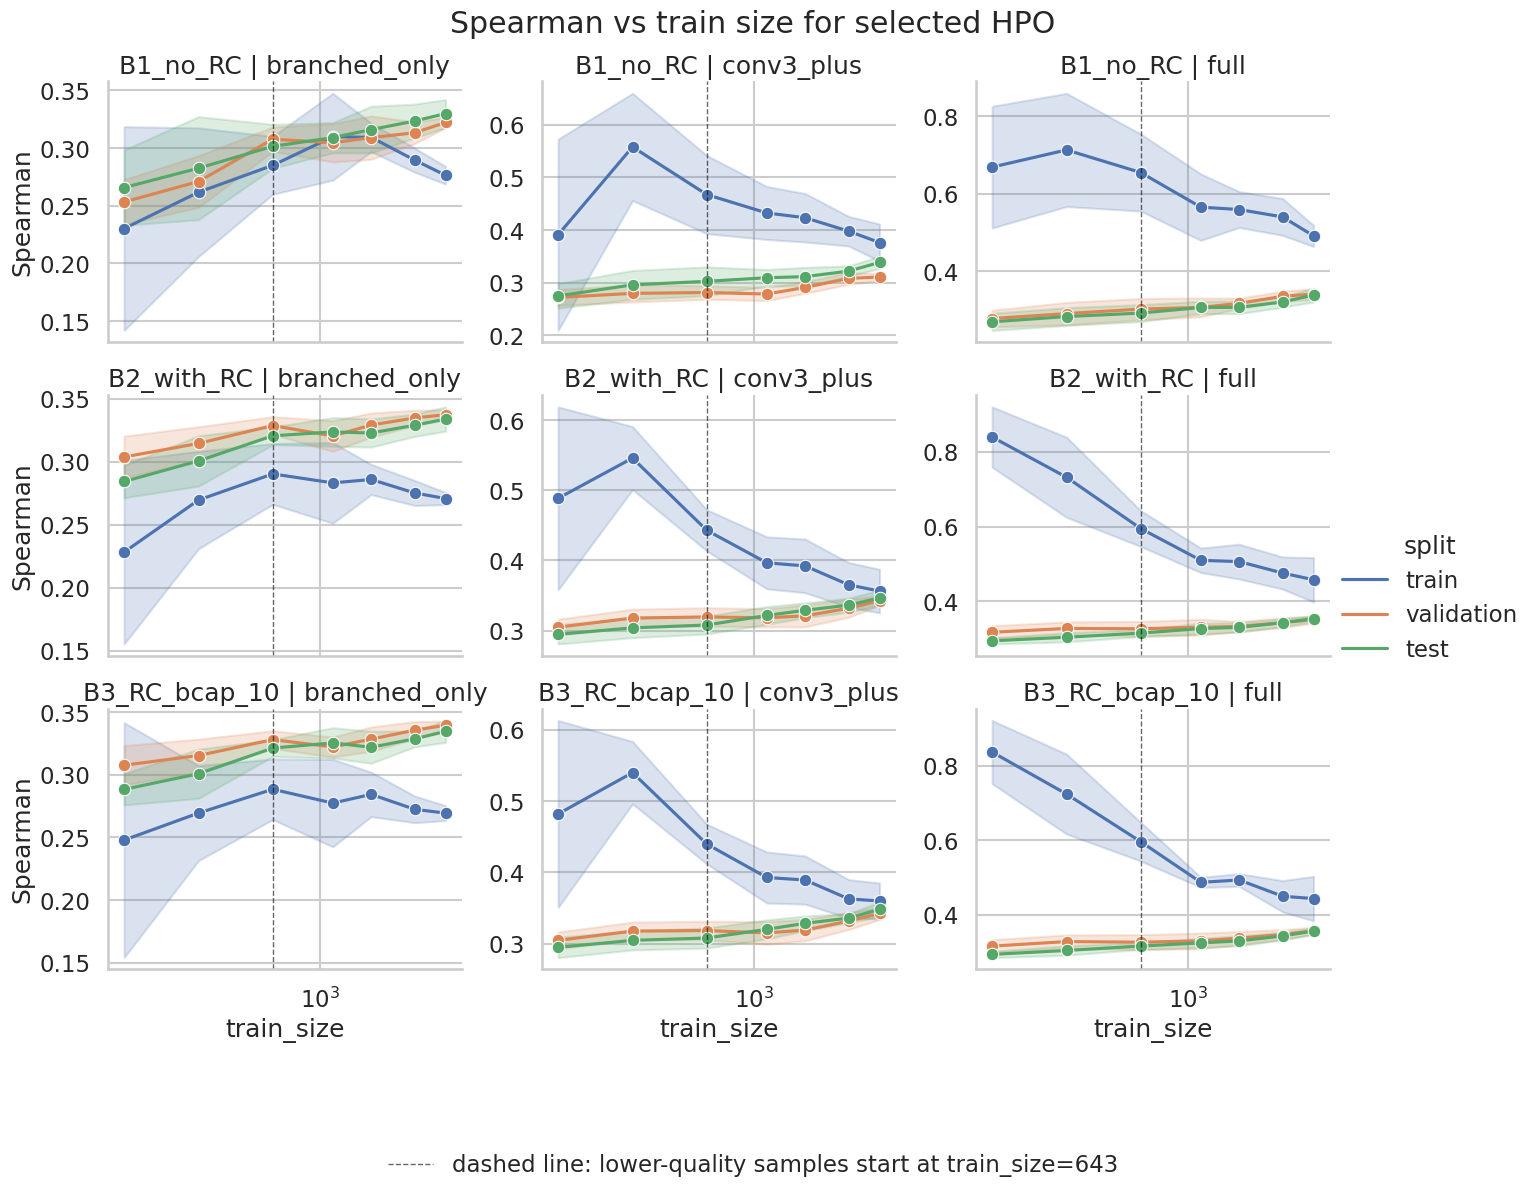

In [6]:
final_metric_frame = best_runs.query("train_threshold == 1").copy()

for metric_root, y_label in [
    ("r2", "R2"),
    ("pearson", "Pearson"),
    ("spearman", "Spearman"),
]:
    plot_final_metric_vs_train_size(final_metric_frame, metric_root, y_label)
    plt.show()

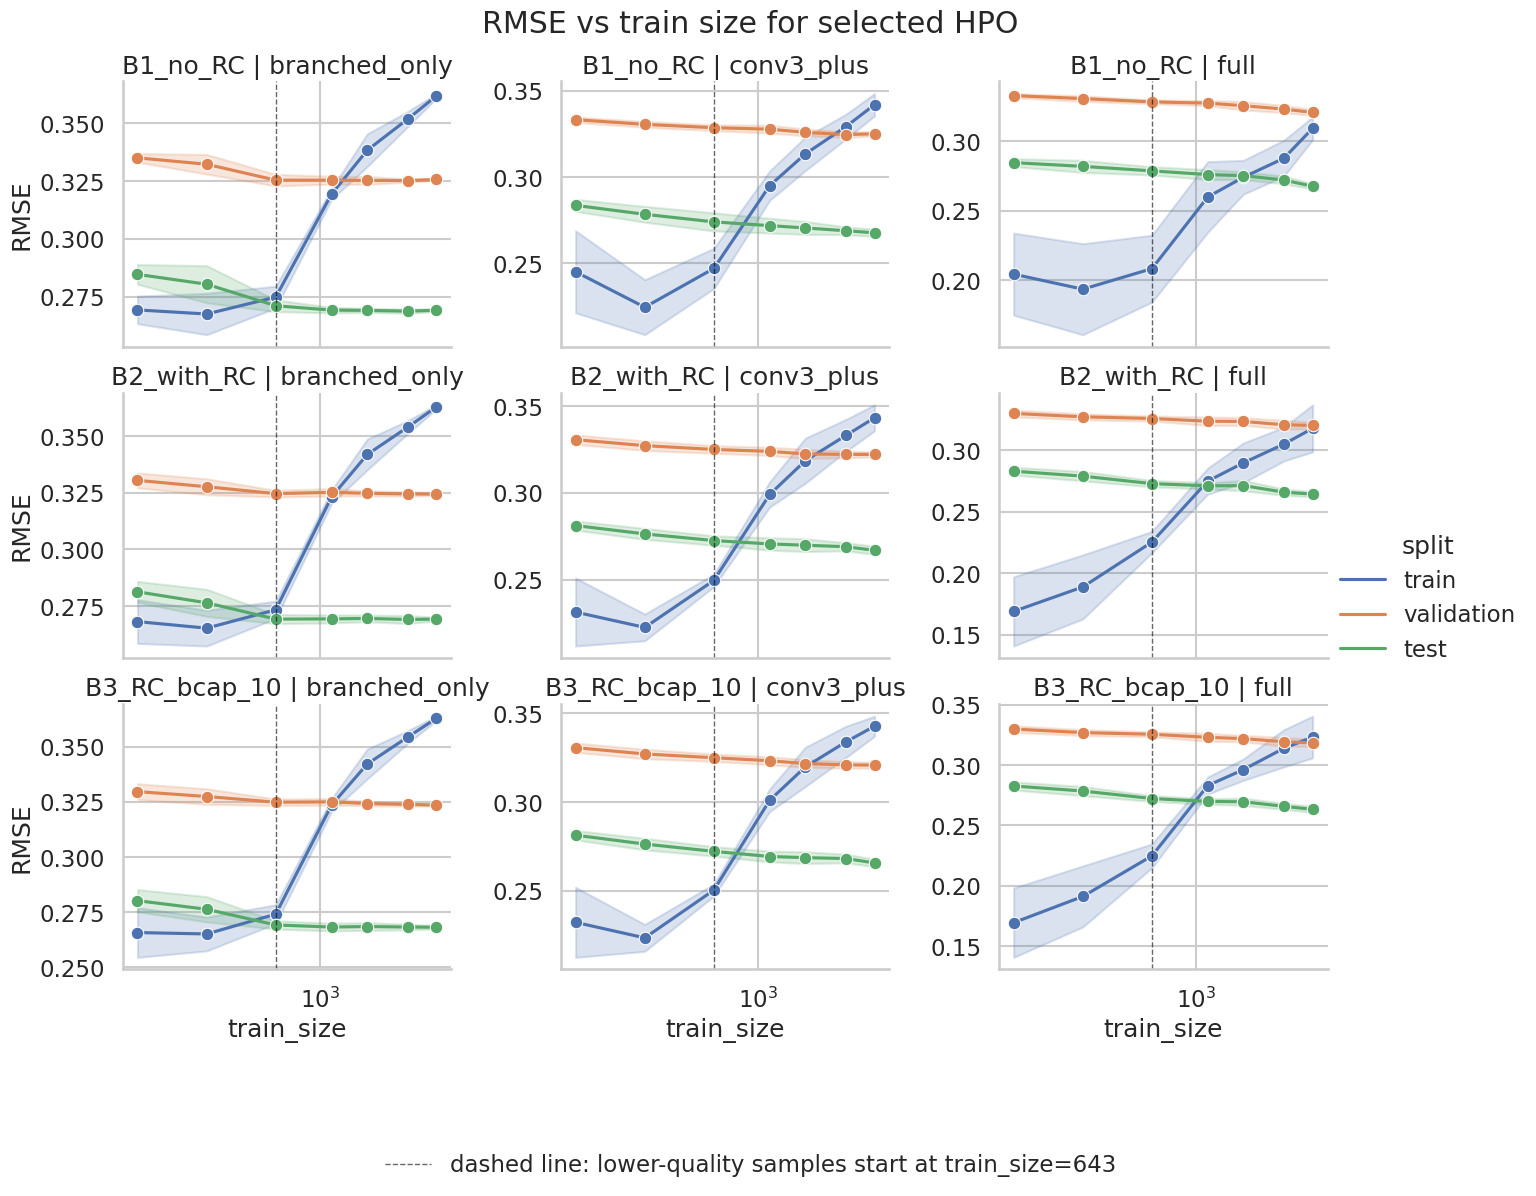

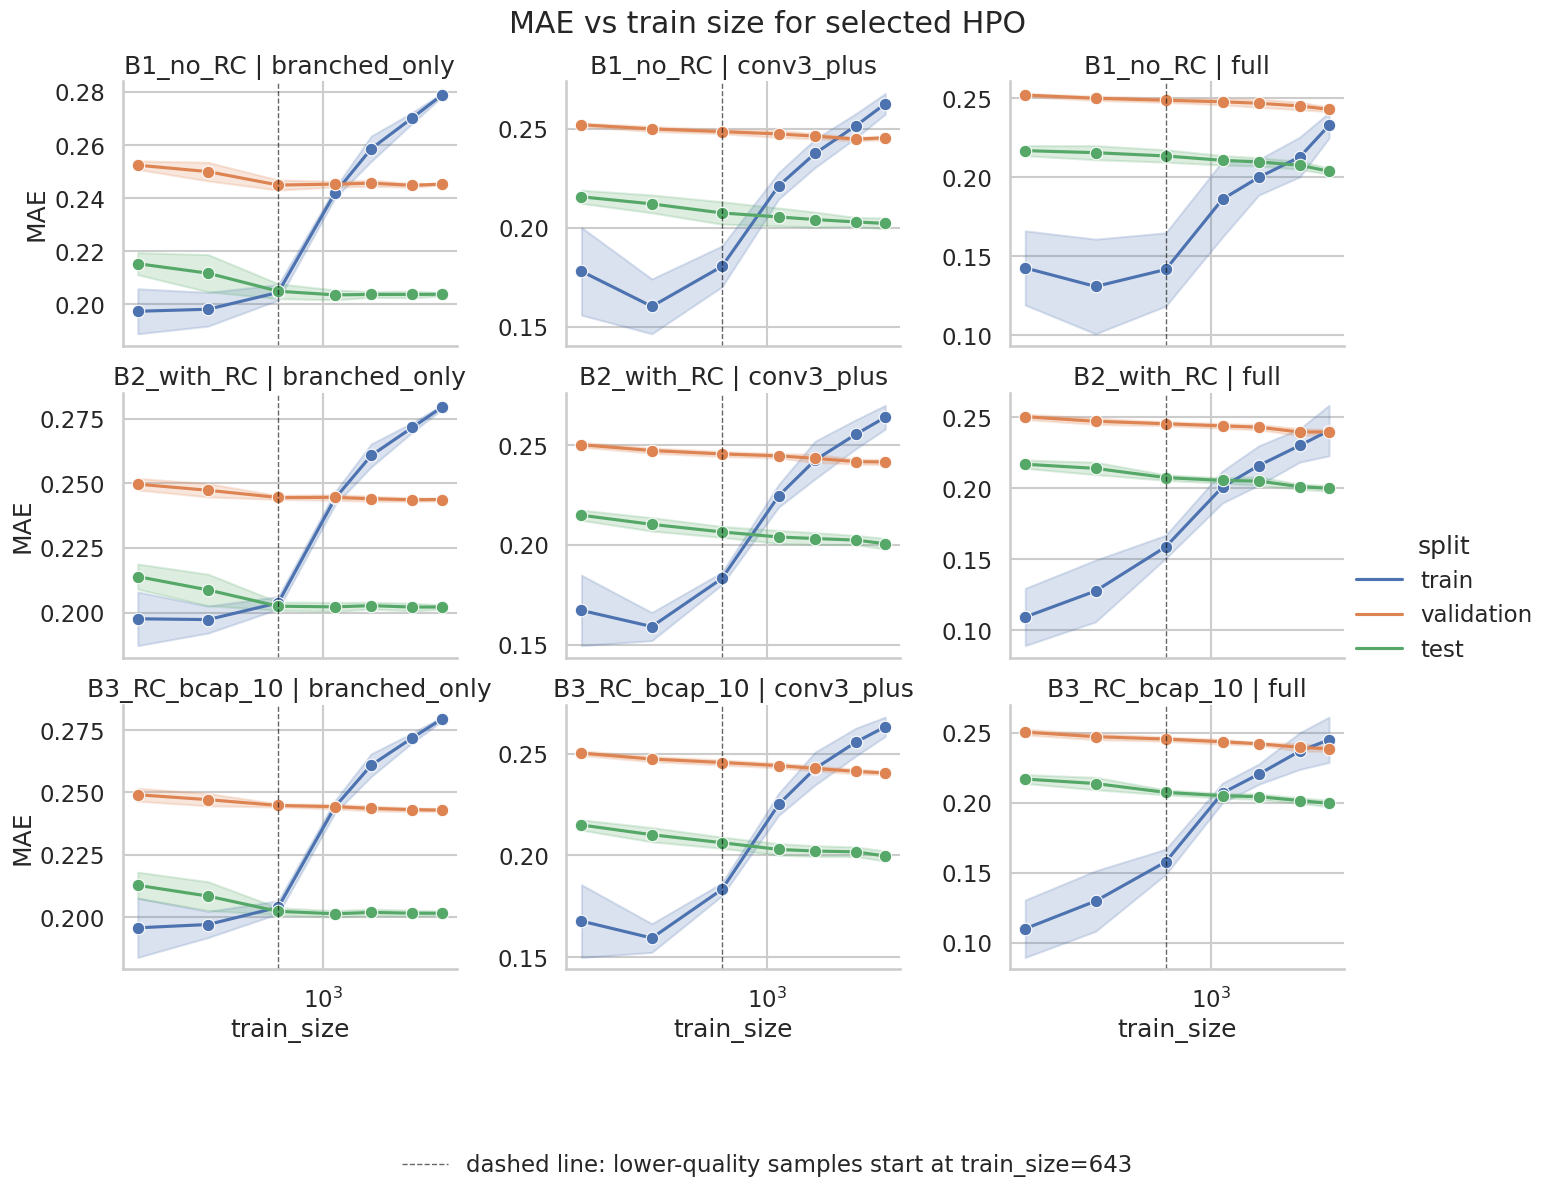

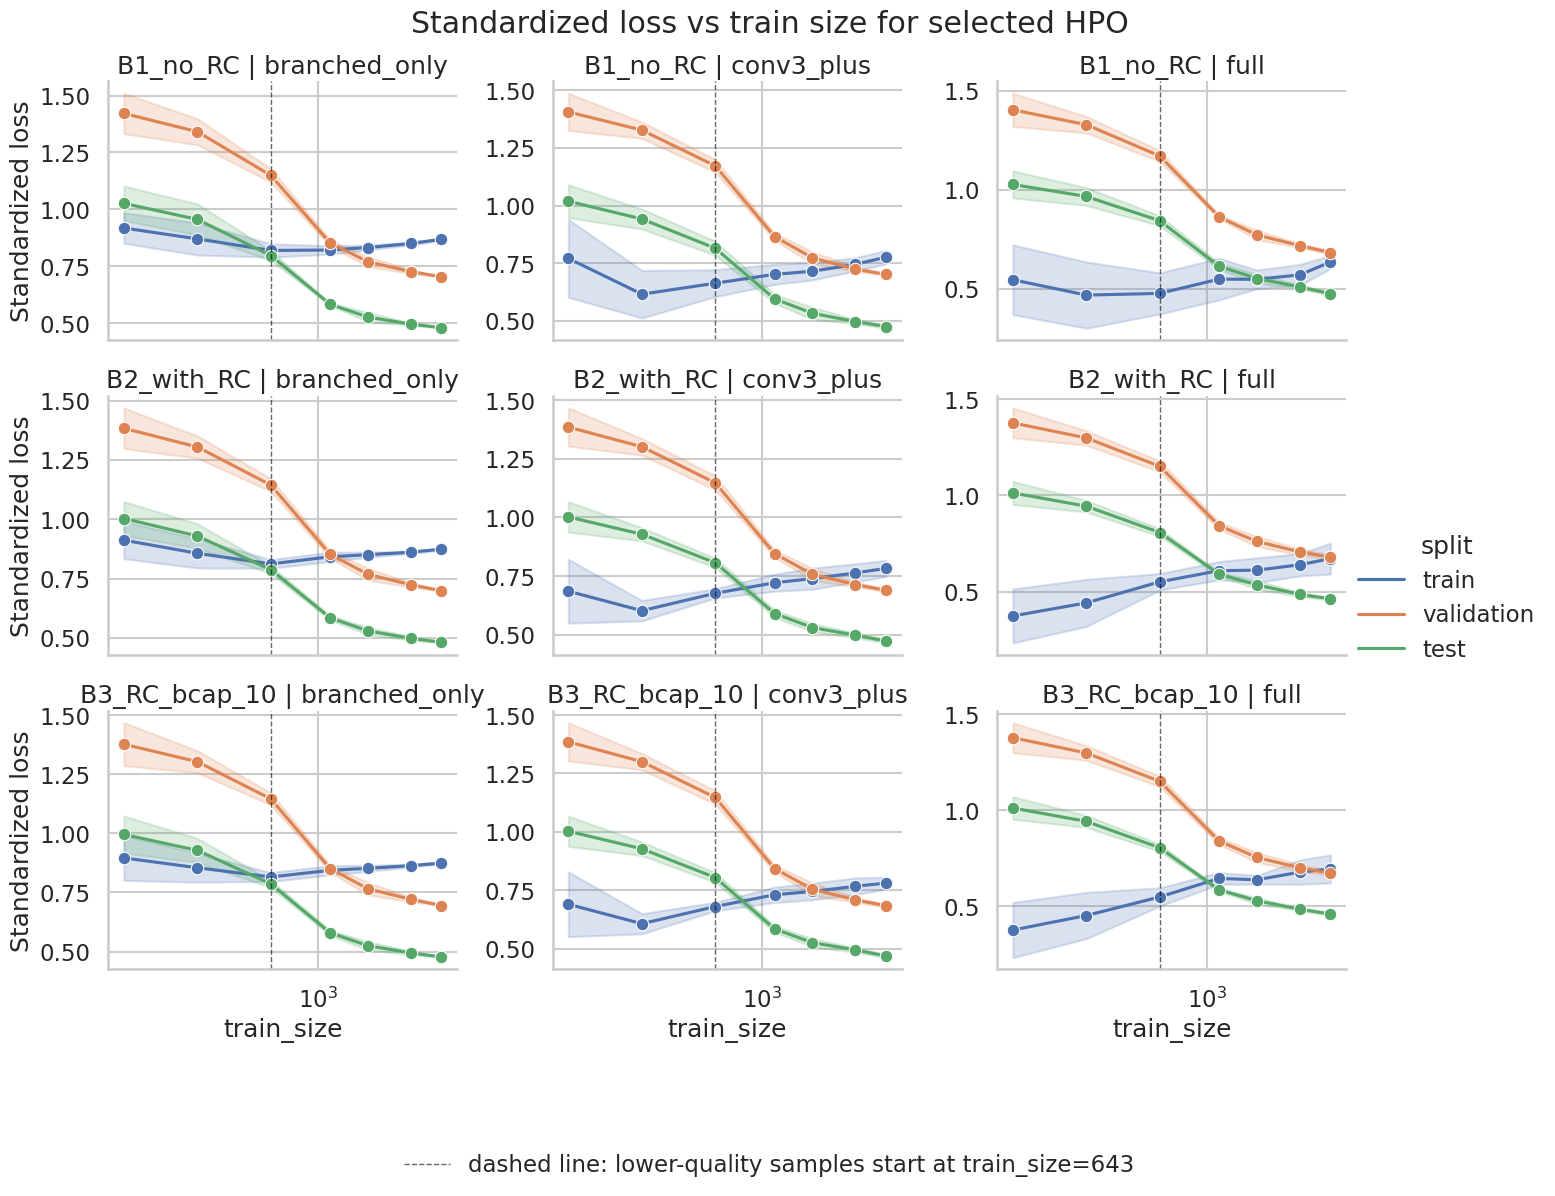

In [7]:
for metric_root, y_label in [
    ("rmse", "RMSE"),
    ("mae", "MAE"),
    ("loss_standardized", "Standardized loss"),
]:
    plot_final_metric_vs_train_size(final_metric_frame, metric_root, y_label)
    plt.show()

## Early-stop Epoch vs. training size

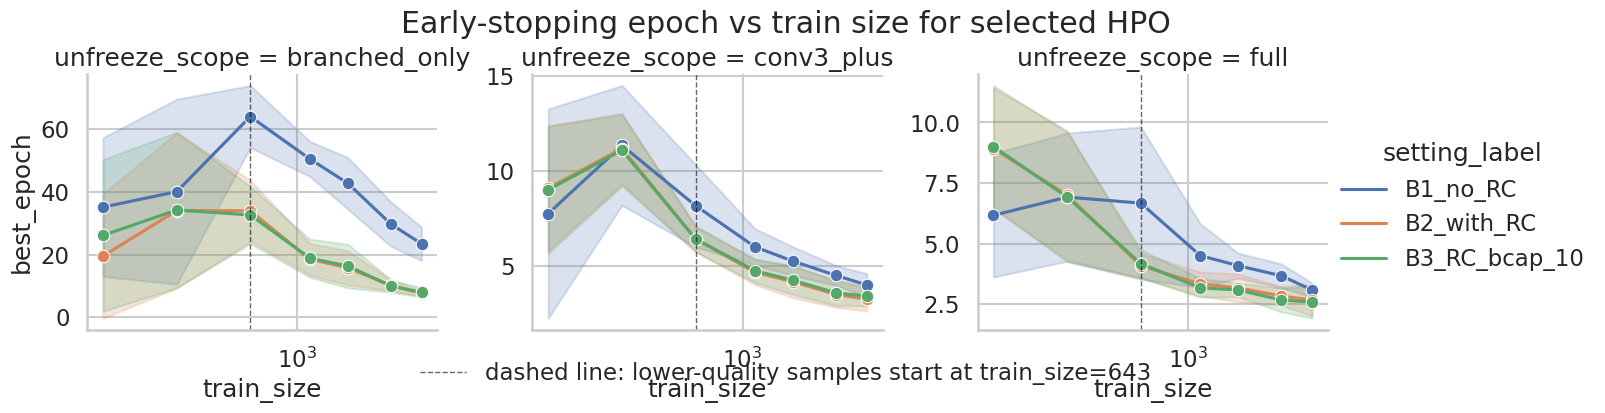

,setting,unfreeze_scope,initial_trainable_params,final_trainable_params,total_params
0,B1_no_RC,branched_only,179761,179761,3747661
1,B1_no_RC,conv3_plus,179761,3063361,3747661
2,B1_no_RC,full,179761,3747661,3747661
3,B2_with_RC,branched_only,179761,179761,3747661
4,B2_with_RC,conv3_plus,179761,3063361,3747661
5,B2_with_RC,full,179761,3747661,3747661
6,B3_with_RC_weighted_bcap_10,branched_only,179761,179761,3747661
7,B3_with_RC_weighted_bcap_10,conv3_plus,179761,3063361,3747661
8,B3_with_RC_weighted_bcap_10,full,179761,3747661,3747661


In [8]:
best_epoch_plot_df = final_metric_frame.copy()
best_epoch_plot_df["setting_label"] = best_epoch_plot_df["setting"].map(SETTING_LABEL_MAP).fillna(best_epoch_plot_df["setting"])

g = sns.relplot(
    data=best_epoch_plot_df,
    x="train_size",
    y="best_epoch",
    hue="setting_label",
    col="unfreeze_scope",
    kind="line",
    marker="o",
    estimator="mean",
    errorbar="sd",
    height=4,
    aspect=1.15,
    facet_kws={"sharex": True, "sharey": False},
)
g.set(xscale="log")
g.set_axis_labels("train_size", "best_epoch")
g.set_titles("unfreeze_scope = {col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Early-stopping epoch vs train size for selected HPO", y=0.98)
add_quality_transition_marker(g)
plt.show()

display(
    final_metric_frame.groupby(["setting", "unfreeze_scope"], dropna=False)[
        ["initial_trainable_params", "final_trainable_params", "total_params"]
    ]
    .first()
    .reset_index()
    .sort_values(["setting", "unfreeze_scope"])
)

## double y-axes eval & early stop epoch vs. x-axis training size

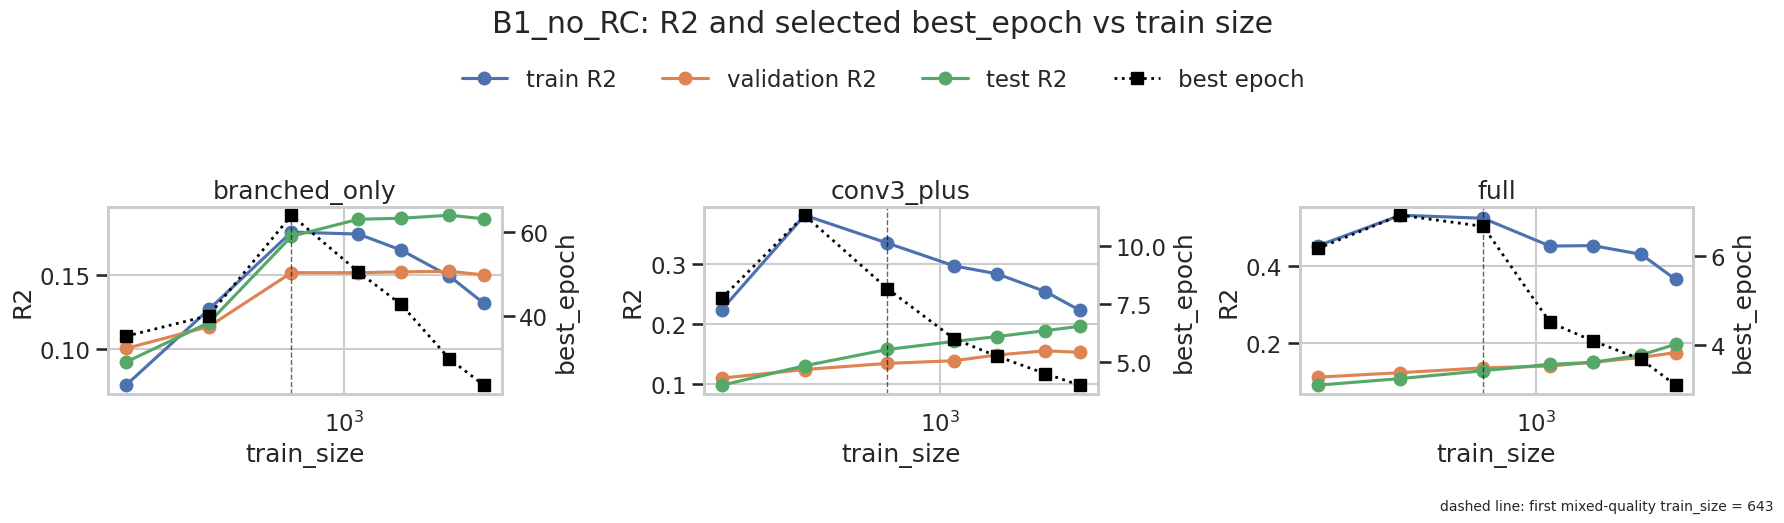

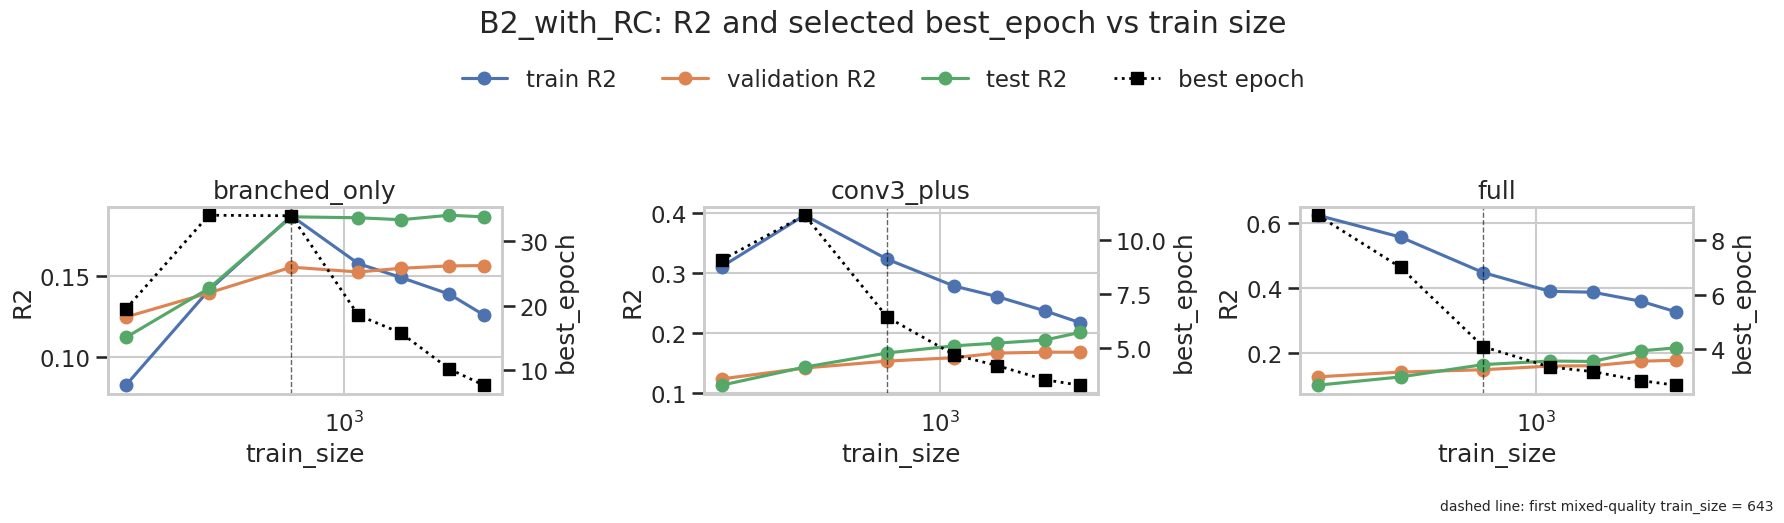

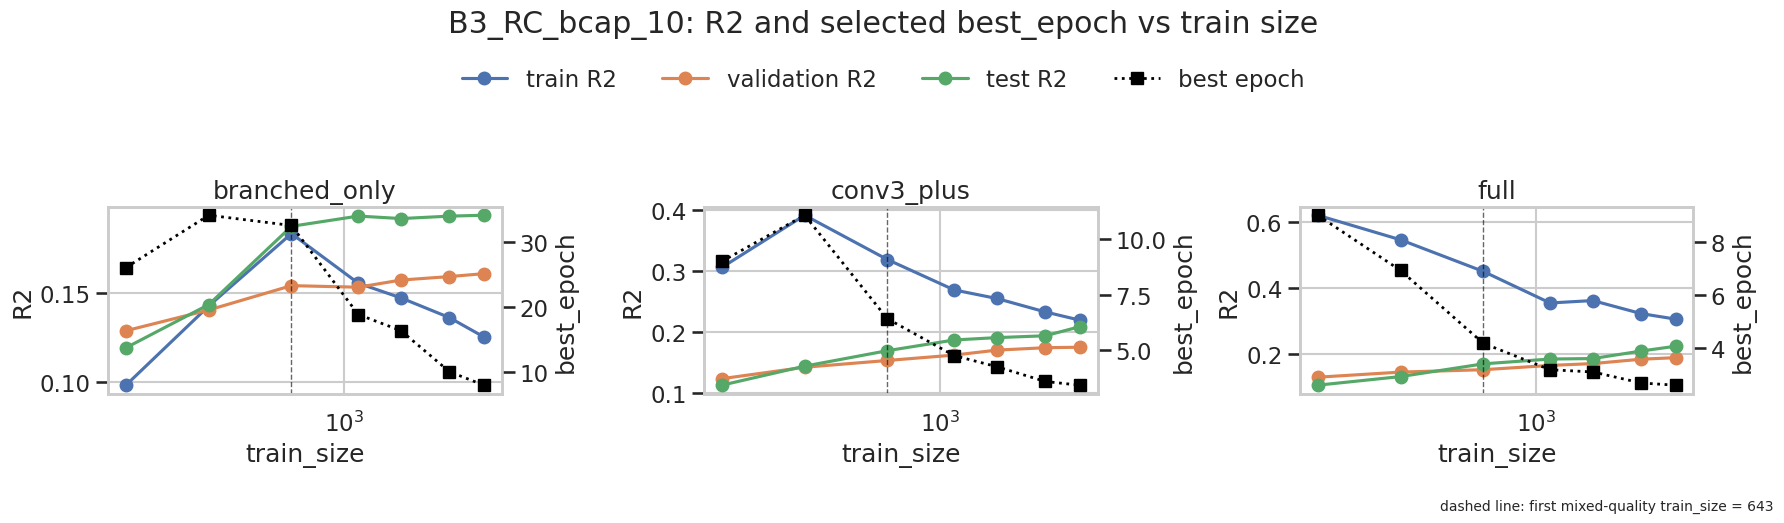

In [9]:
summary_plot_df = (
    final_metric_frame.groupby(["setting", "unfreeze_scope", "train_size"], dropna=False)
    .agg(
        train_r2_mean=("train_r2", "mean"),
        val_r2_mean=("val_r2", "mean"),
        test_r2_mean=("test_r2", "mean"),
        best_epoch_mean=("best_epoch", "mean"),
        train_hq_fraction_mean=("train_hq_fraction", "mean"),
    )
    .reset_index()
)
summary_plot_df["setting_label"] = summary_plot_df["setting"].map(SETTING_LABEL_MAP).fillna(summary_plot_df["setting"])

for setting_label in summary_plot_df["setting_label"].unique():
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
    setting_df = summary_plot_df[summary_plot_df["setting_label"] == setting_label].copy()
    legend_handles = None
    legend_labels = None

    for ax, scope in zip(axes, ["branched_only", "conv3_plus", "full"]):
        sub = setting_df[setting_df["unfreeze_scope"] == scope].sort_values("train_size")
        if sub.empty:
            ax.set_visible(False)
            continue

        ax.plot(sub["train_size"], sub["train_r2_mean"], marker="o", label="train R2", color="#4c72b0")
        ax.plot(sub["train_size"], sub["val_r2_mean"], marker="o", label="validation R2", color="#dd8452")
        ax.plot(sub["train_size"], sub["test_r2_mean"], marker="o", label="test R2", color="#55a868")
        ax.set_xscale("log")
        ax.set_xlabel("train_size")
        ax.set_ylabel("R2")
        ax.set_title(scope)
        ax.axvline(first_mixed_train_size, color="black", linestyle="--", linewidth=1.0, alpha=0.6)

        ax2 = ax.twinx()
        ax2.plot(
            sub["train_size"],
            sub["best_epoch_mean"],
            marker="s",
            linestyle=":",
            linewidth=2,
            color="black",
            label="best epoch",
        )
        ax2.set_ylabel("best_epoch")
        ax2.grid(False)

        if legend_handles is None:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            legend_handles = lines1 + lines2
            legend_labels = labels1 + labels2

    fig.suptitle(f"{setting_label}: R2 and selected best_epoch vs train size", y=1.06)
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=len(legend_labels),
            frameon=False,
        )
    fig.text(
        0.995,
        0.01,
        f"dashed line: first mixed-quality train_size = {first_mixed_train_size}",
        ha="right",
        va="bottom",
        fontsize=10,
    )
    fig.tight_layout(rect=[0, 0.05, 1, 0.88])
    plt.show()

In [10]:
side_by_side_table = (
    final_metric_frame.groupby(["setting", "unfreeze_scope", "train_size"], dropna=False)
    .agg(
        train_hq_fraction=("train_hq_fraction", "mean"),
        best_epoch=("best_epoch", "mean"),
        train_r2=("train_r2", "mean"),
        val_r2=("val_r2", "mean"),
        test_r2=("test_r2", "mean"),
        train_pearson=("train_pearson", "mean"),
        val_pearson=("val_pearson", "mean"),
        test_pearson=("test_pearson", "mean"),
    )
    .reset_index()
    .sort_values(["setting", "unfreeze_scope", "train_size"])
)
side_by_side_table["setting"] = side_by_side_table["setting"].map(SETTING_LABEL_MAP).fillna(side_by_side_table["setting"])

display(side_by_side_table)

,setting,unfreeze_scope,train_size,train_hq_fraction,best_epoch,train_r2,val_r2,test_r2,train_pearson,val_pearson,test_pearson
0,B1_no_RC,branched_only,161,1.000000,35.083333,0.075711,0.100431,0.091263,0.308056,0.319469,0.312677
1,B1_no_RC,branched_only,322,1.000000,40.000000,0.126673,0.115153,0.117770,0.365532,0.343438,0.351435
2,B1_no_RC,branched_only,643,0.954899,63.916667,0.178792,0.151464,0.175967,0.424255,0.390335,0.420975
3,B1_no_RC,branched_only,1125,0.545778,50.416667,0.177450,0.151442,0.187434,0.423410,0.392960,0.435988
4,B1_no_RC,branched_only,1608,0.381841,42.666667,0.166707,0.152001,0.188102,0.410563,0.396000,0.438512
...,...,...,...,...,...,...,...,...,...,...,...
58,B3_RC_bcap_10,full,643,0.954899,4.166667,0.449787,0.150836,0.168573,0.693477,0.389856,0.416306
59,B3_RC_bcap_10,full,1125,0.545778,3.166667,0.353707,0.163851,0.183268,0.610870,0.408611,0.439878
60,B3_RC_bcap_10,full,1608,0.381841,3.083333,0.361031,0.169434,0.184714,0.610681,0.420923,0.454531
61,B3_RC_bcap_10,full,2411,0.254666,2.666667,0.321372,0.182743,0.207586,0.576149,0.433200,0.468901


## Eval Metrics (loss, R2, R) over epochs

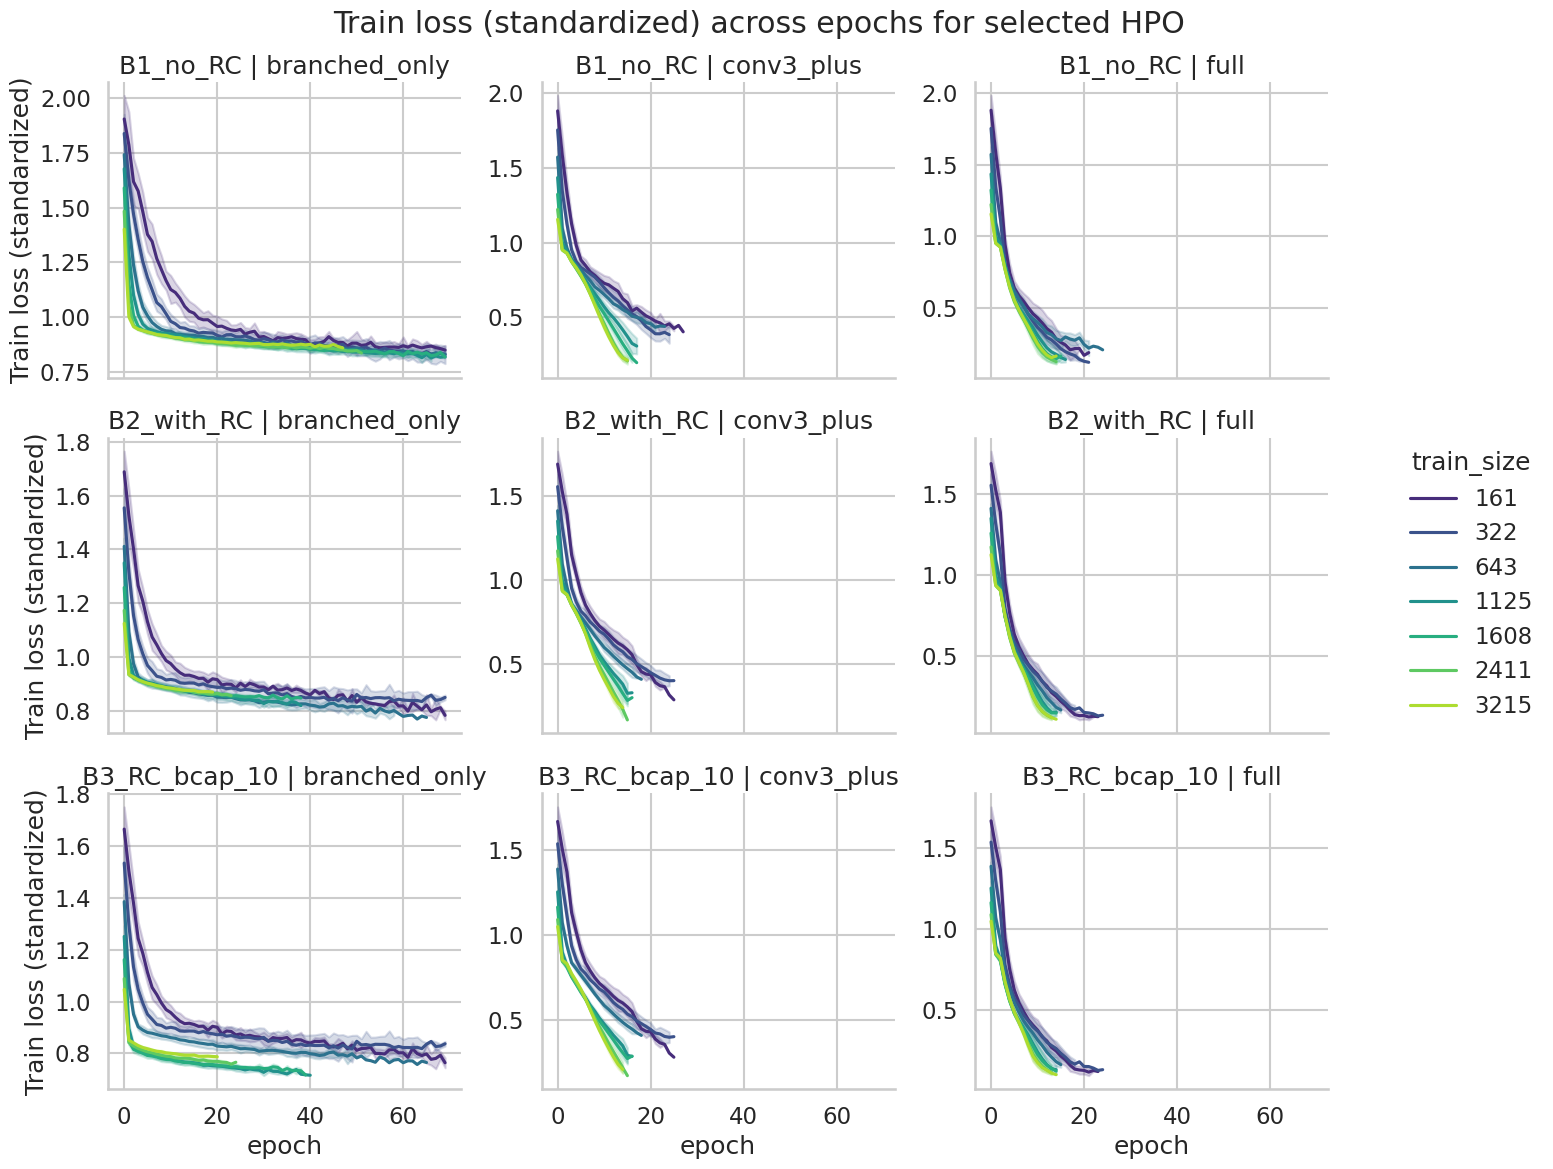

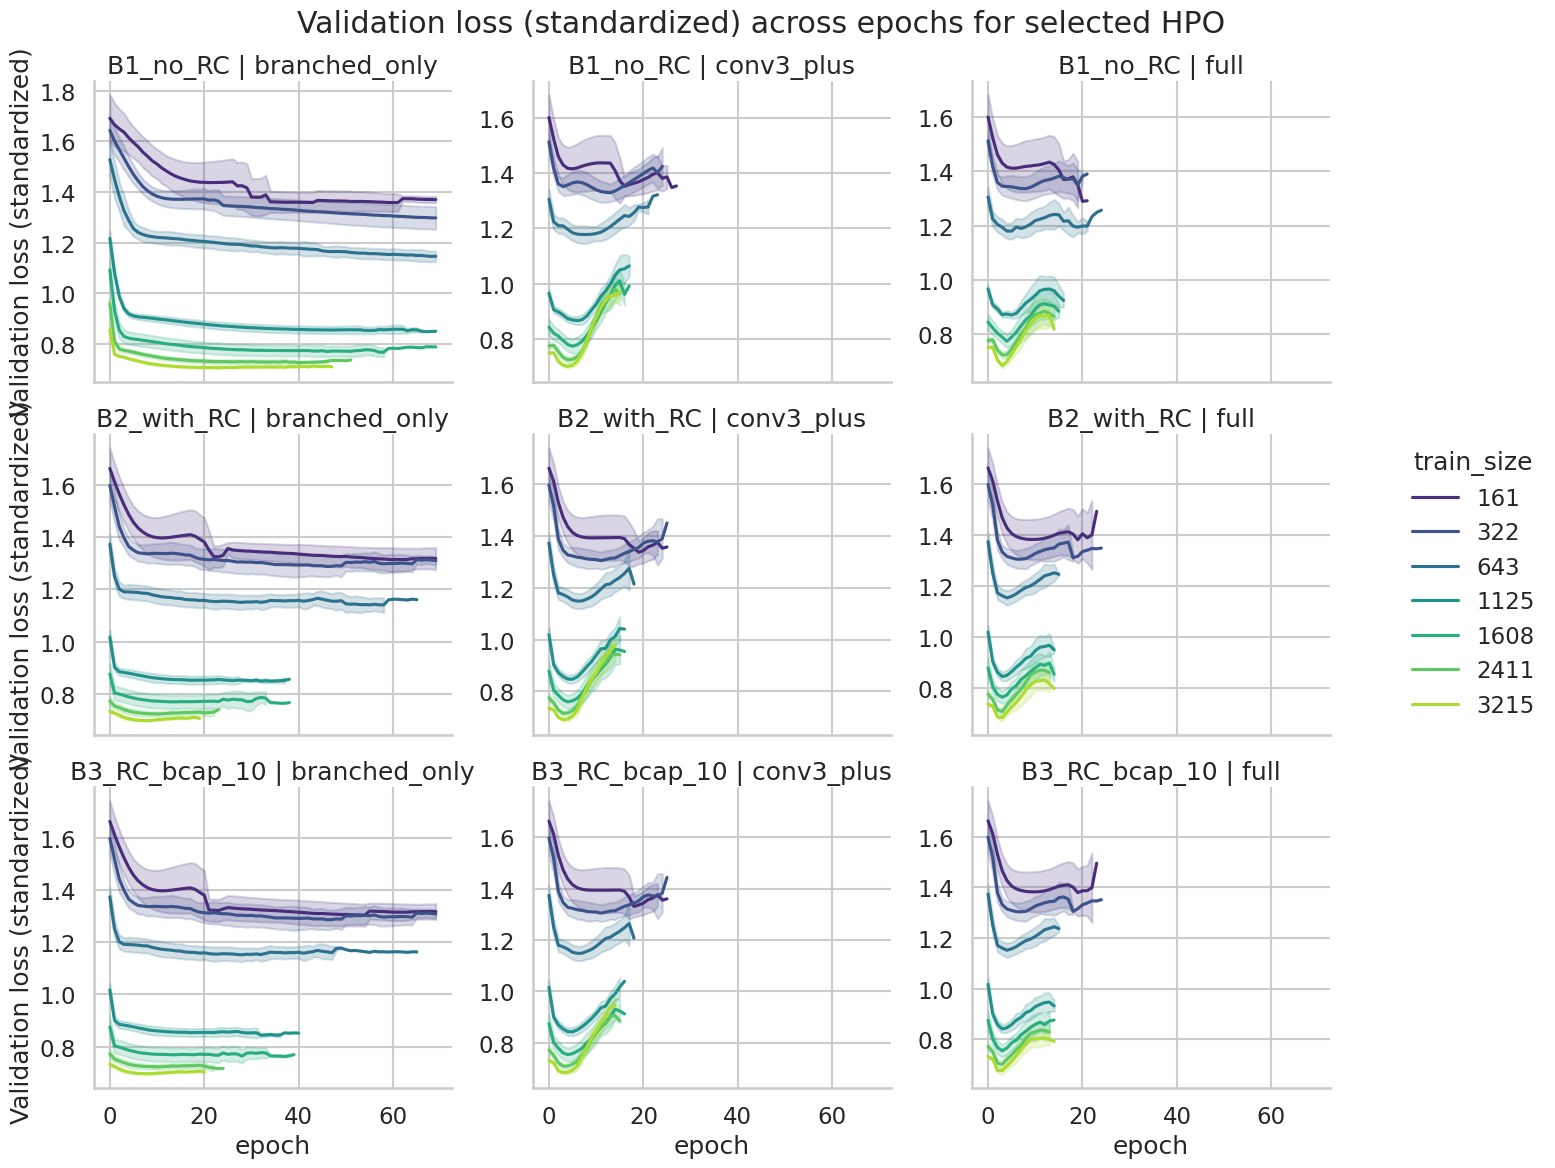

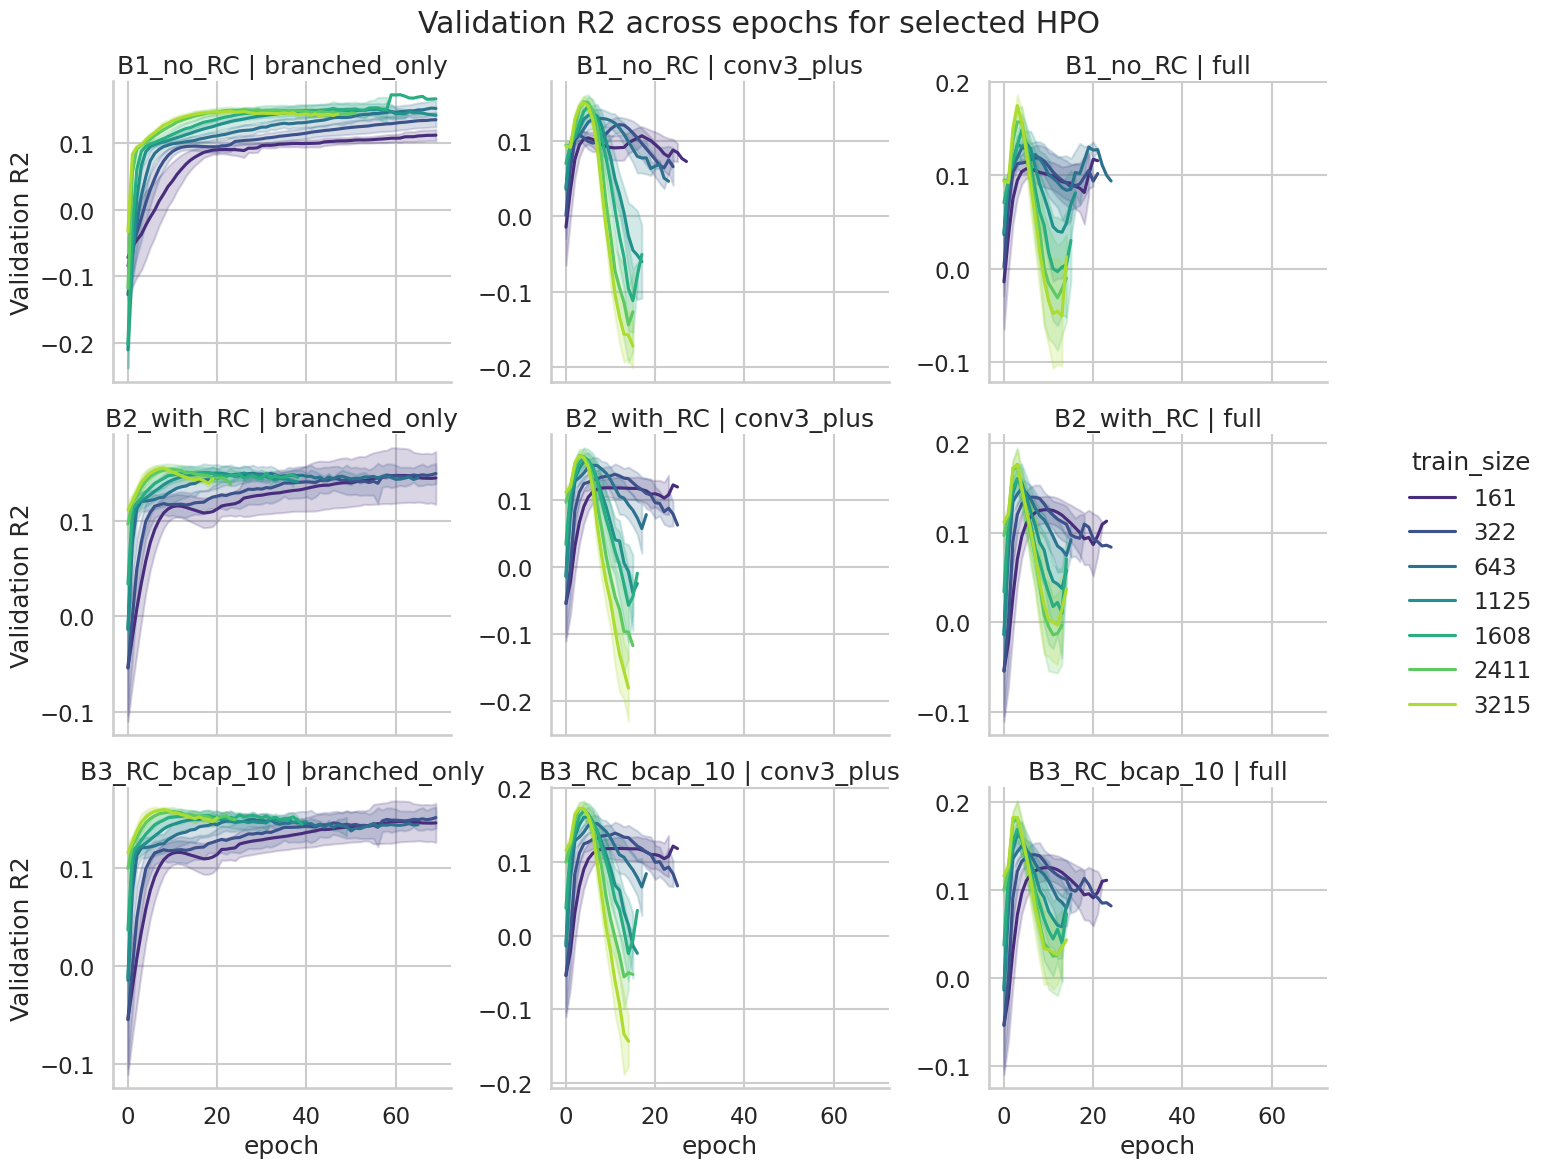

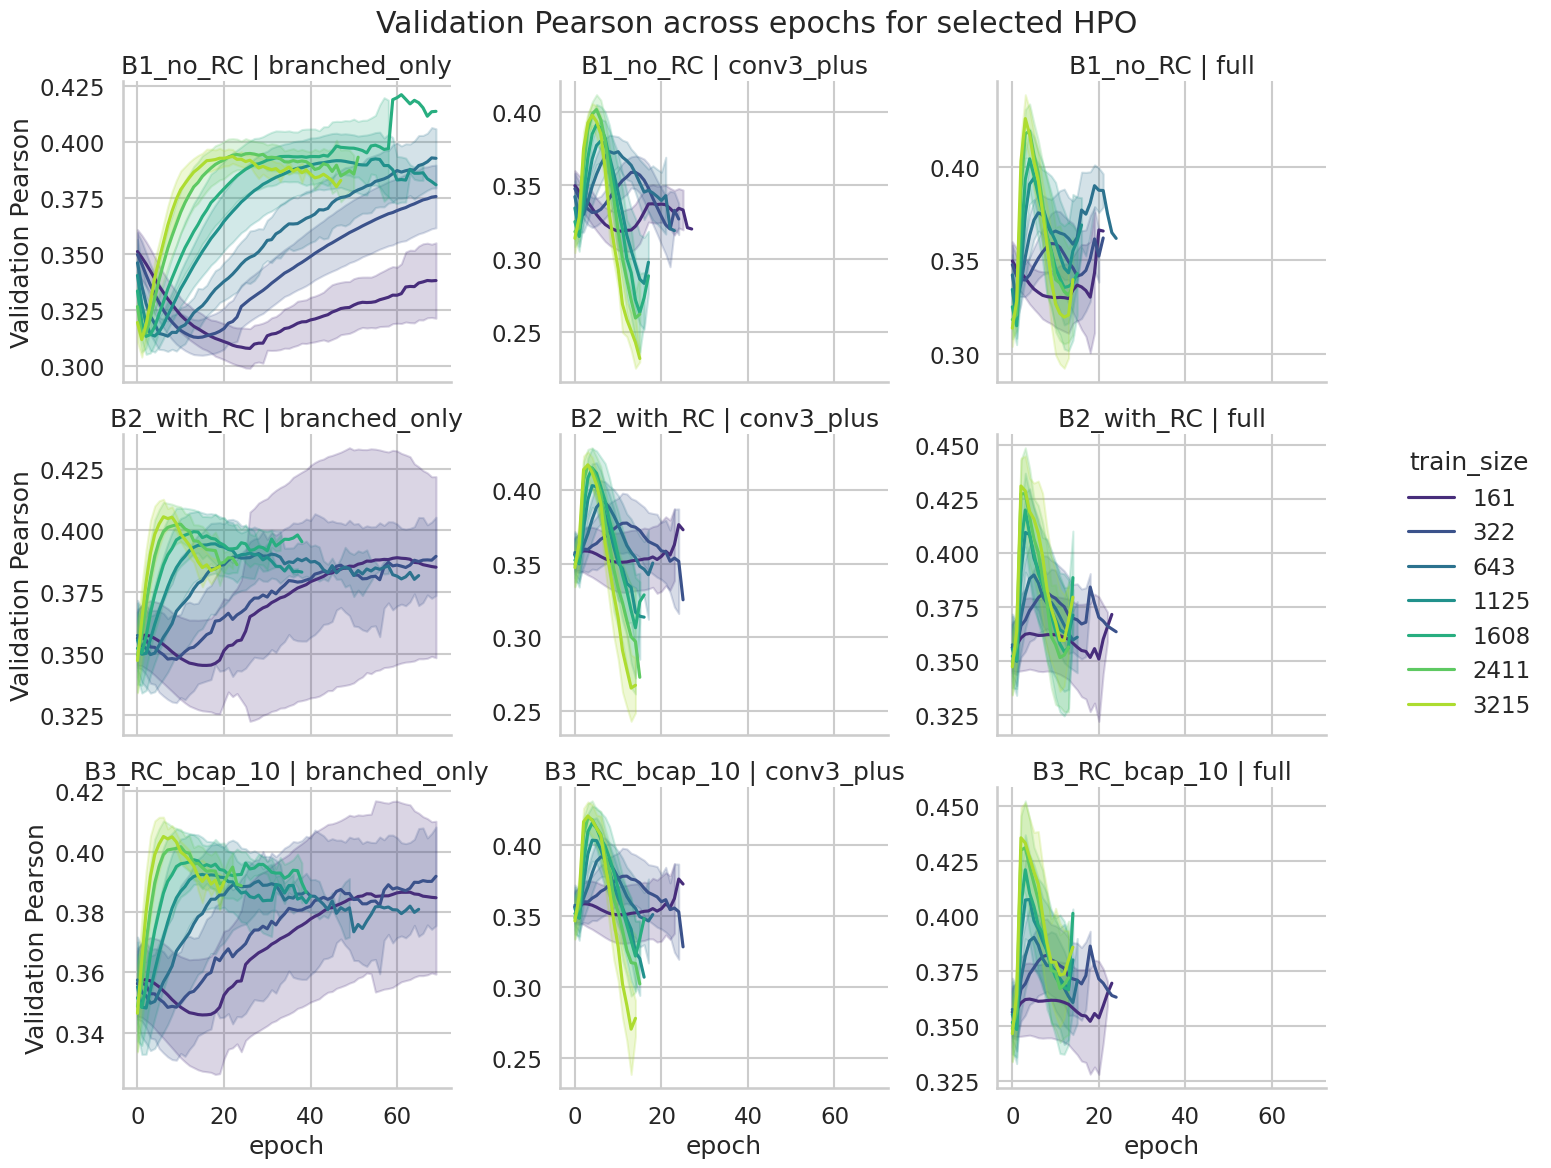

In [11]:
epoch_metric_frame = best_histories.query("train_threshold == 1").copy()

for metric_col, y_label in [
    ("train_loss_standardized", "Train loss (standardized)"),
    ("val_loss_standardized", "Validation loss (standardized)"),
    ("val_r2", "Validation R2"),
    ("val_pearson", "Validation Pearson"),
]:
    plot_epoch_metric(epoch_metric_frame, metric_col, y_label)
    plt.show()

### B2_with_RC at largest train size: train and validation loss over epochs

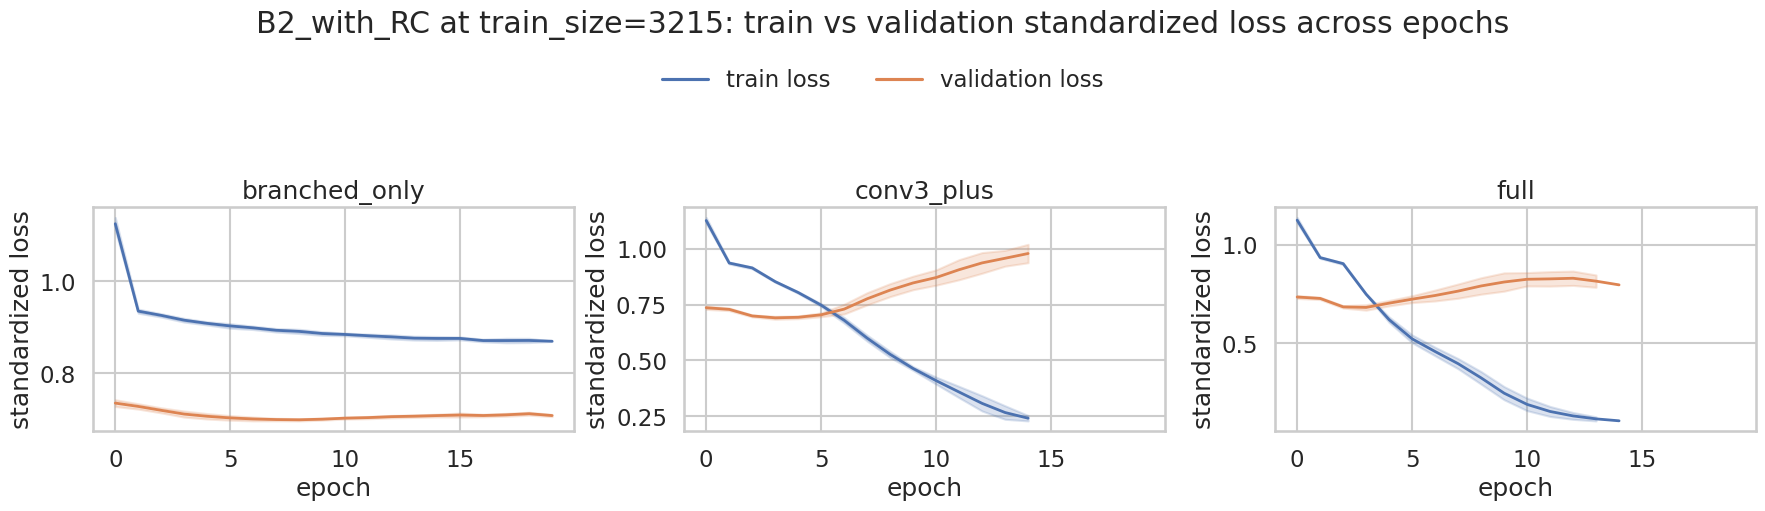

In [12]:
b2_setting = "B2_with_RC"
scope_order = ["branched_only", "conv3_plus", "full"]
largest_train_size = int(max(train_size_order))

b2_full_size_epoch_loss = best_histories.query(
    "train_threshold == 1 and setting == @b2_setting and train_size == @largest_train_size"
).copy()

loss_plot_df = b2_full_size_epoch_loss.melt(
    id_vars=["unfreeze_scope", "epoch", "seed", "init_head"],
    value_vars=["train_loss_standardized", "val_loss_standardized"],
    var_name="split",
    value_name="loss",
)
loss_plot_df["split"] = loss_plot_df["split"].map(
    {
        "train_loss_standardized": "train loss",
        "val_loss_standardized": "validation loss",
    }
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
legend_handles = None
legend_labels = None

for ax, scope in zip(axes, scope_order):
    sub = loss_plot_df[loss_plot_df["unfreeze_scope"] == scope].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    sns.lineplot(
        data=sub,
        x="epoch",
        y="loss",
        hue="split",
        hue_order=["train loss", "validation loss"],
        palette={"train loss": "#4c72b0", "validation loss": "#dd8452"},
        estimator="mean",
        errorbar="sd",
        linewidth=2,
        ax=ax,
    )
    ax.set_title(scope)
    ax.set_xlabel("epoch")
    ax.set_ylabel("standardized loss")

    handles, labels = ax.get_legend_handles_labels()
    if legend_handles is None:
        legend_handles = handles
        legend_labels = labels
    if ax.legend_ is not None:
        ax.legend_.remove()

if legend_handles is not None:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(legend_labels),
        frameon=False,
    )

fig.suptitle(
    f"B2_with_RC at train_size={largest_train_size}: train vs validation standardized loss across epochs",
    y=1.08,
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

### B2_with_RC across all train sizes: validation R2 over epochs

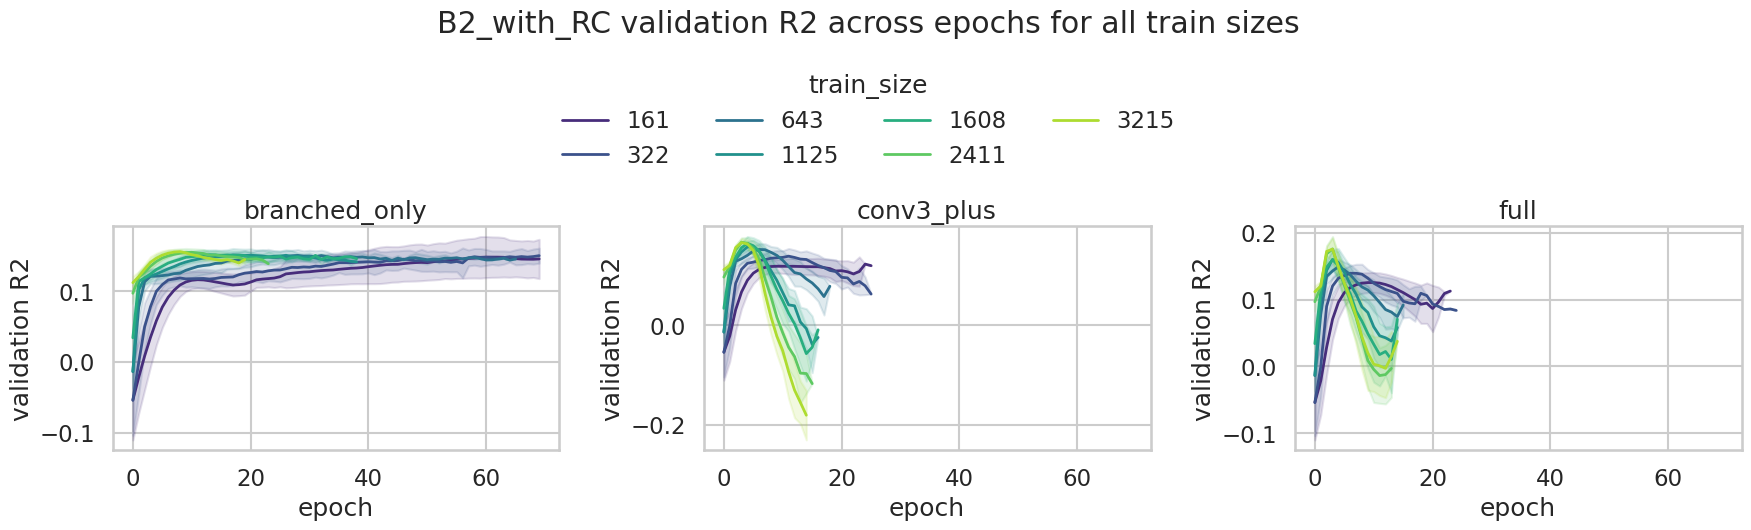

In [13]:
from matplotlib.lines import Line2D

b2_setting = "B2_with_RC"
scope_order = ["branched_only", "conv3_plus", "full"]
train_size_order_int = [int(x) for x in train_size_order]
train_size_palette = dict(zip(train_size_order_int, sns.color_palette("viridis", n_colors=len(train_size_order_int))))

b2_val_r2 = best_histories.query(
    "train_threshold == 1 and setting == @b2_setting"
).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=False)

for ax, scope in zip(axes, scope_order):
    scope_df = b2_val_r2[b2_val_r2["unfreeze_scope"] == scope].copy()
    if scope_df.empty:
        ax.set_visible(False)
        continue

    for train_size in train_size_order_int:
        size_df = scope_df[scope_df["train_size"] == train_size].copy()
        if size_df.empty:
            continue

        epoch_summary = (
            size_df.groupby("epoch", dropna=False)["val_r2"]
            .agg(["mean", "std"])
            .reset_index()
            .rename(columns={"mean": "val_r2_mean", "std": "val_r2_sd"})
        )
        y = epoch_summary["val_r2_mean"].to_numpy()
        err = epoch_summary["val_r2_sd"].fillna(0).to_numpy()
        color = train_size_palette[train_size]

        ax.plot(epoch_summary["epoch"], y, color=color, linewidth=2)
        ax.fill_between(epoch_summary["epoch"], y - err, y + err, color=color, alpha=0.15)

    ax.set_title(scope)
    ax.set_xlabel("epoch")
    ax.set_ylabel("validation R2")

legend_handles = [
    Line2D([0], [0], color=train_size_palette[train_size], linewidth=2, label=str(train_size))
    for train_size in train_size_order_int
]
fig.legend(
    legend_handles,
    [str(train_size) for train_size in train_size_order_int],
    title="train_size",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    frameon=False,
)
fig.suptitle("B2_with_RC validation R2 across epochs for all train sizes", y=1.12)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

### At largest train size 3215, [train-, val-] standardized loss over epochs

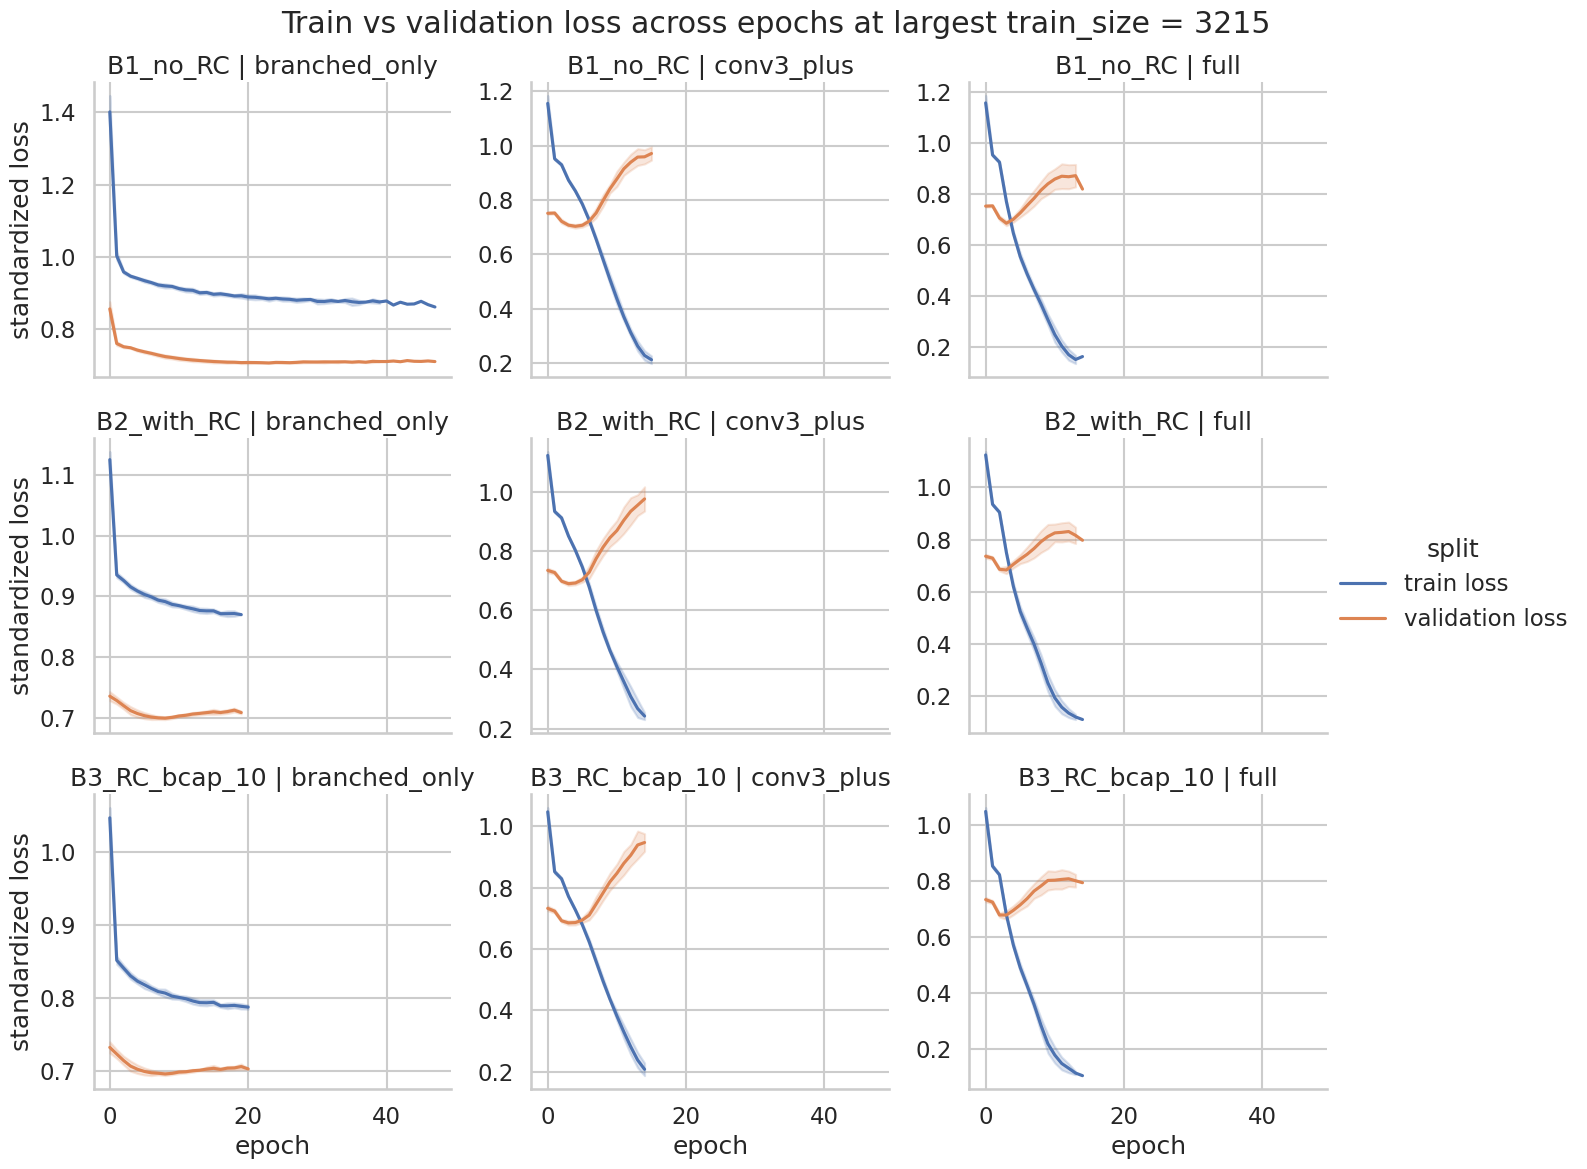

In [14]:
largest_train_size = max(train_size_order)
full_size_epoch_loss = best_histories.loc[best_histories["train_size"] == largest_train_size].copy()
full_size_epoch_loss["setting_label"] = full_size_epoch_loss["setting"].map(SETTING_LABEL_MAP).fillna(full_size_epoch_loss["setting"])

loss_plot_df = full_size_epoch_loss.melt(
    id_vars=["setting_label", "unfreeze_scope", "epoch", "seed", "init_head"],
    value_vars=["train_loss_standardized", "val_loss_standardized"],
    var_name="split",
    value_name="loss",
)
loss_plot_df["split"] = loss_plot_df["split"].map(
    {
        "train_loss_standardized": "train loss",
        "val_loss_standardized": "validation loss",
    }
)

g = sns.relplot(
    data=loss_plot_df,
    x="epoch",
    y="loss",
    hue="split",
    row="setting_label",
    col="unfreeze_scope",
    kind="line",
    estimator="mean",
    errorbar="sd",
    height=4,
    aspect=1.15,
    facet_kws={"sharex": True, "sharey": False},
)
g.set_axis_labels("epoch", "standardized loss")
g.set_titles("{row_name} | {col_name}")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle(f"Train vs validation loss across epochs at largest train_size = {largest_train_size}")
plt.show()

## Notes

- The train-size curves above use one selected HPO point per `setting x unfreeze_scope`, chosen from the full-train-size (`n=max`) grid by mean validation R2.
- The final-metric plots aggregate over seeds and initialization heads with mean lines and standard-deviation error bars.
- The epoch plots are limited to what the runner logged each epoch: `train_loss_standardized` and validation metrics.
- If you want a follow-up view broken out by `init_head`, clone the same plotting helpers and add `row="init_head"` or `style="init_head"`.